In [1]:
import numpy as np
import pandas as pd
import json
import os
import csv

import PySAM.Pvwattsv8 as pv_model
import PySAM.ResourceTools as tools

In [2]:
def get_pysam_json(json_file_path):
    """
    Open a PySAM JSON file and return as a dictionary
    """
    with open(json_file_path) as f:
        dic = json.load(f)
    return dic

In [ ]:
sam_api_key = "YOUR_API_KEY"
sam_email = "YOUR_EMAIL"

for year in range (2016, 2024):
    nsrdbfetcher = tools.FetchResourceFiles(
                    tech='solar',
                    nrel_api_key=sam_api_key,
                    nrel_api_email=sam_email,
                    resource_dir="weather_data",
                    resource_year=str(year),
                    resource_type='nsrdb-GOES-aggregated-v4-0-0' )

    lon_lats = []


    lon_lat = (float(-83.67633), float(33.6762))
    lon_lats.append(lon_lat)

    nsrdbfetcher.fetch(lon_lats)


Starting data download for solar using 1 thread workers.
File already exists. Skipping download: weather_data\nsrdb_33.6762_-83.67633_nsrdb-GOES-aggregated-v4-0-0_60_2016.csv

Starting data download for solar using 1 thread workers.
File already exists. Skipping download: weather_data\nsrdb_33.6762_-83.67633_nsrdb-GOES-aggregated-v4-0-0_60_2017.csv

Starting data download for solar using 1 thread workers.
File already exists. Skipping download: weather_data\nsrdb_33.6762_-83.67633_nsrdb-GOES-aggregated-v4-0-0_60_2018.csv

Starting data download for solar using 1 thread workers.
File already exists. Skipping download: weather_data\nsrdb_33.6762_-83.67633_nsrdb-GOES-aggregated-v4-0-0_60_2019.csv

Starting data download for solar using 1 thread workers.
File already exists. Skipping download: weather_data\nsrdb_33.6762_-83.67633_nsrdb-GOES-aggregated-v4-0-0_60_2020.csv

Starting data download for solar using 1 thread workers.
File already exists. Skipping download: weather_data\nsrdb_33.

In [84]:
pv = pv_model.default("PVWattsSingleOwner")

pv_data = get_pysam_json("C:\\Users\\bmirletz\\source\\repos\\pv_repowering\\Studies\\Journal - Simon Solar captest\\SAM_json\\Simon_pvwattsv8.json")

for key, value in pv_data.items():
    try:
        pv.value(key, value)
    except AttributeError:
         print("Failed to assign PV key " + str(key))

gen_dict = {"hourly": {},
            "monthly": {}}

for year in range (2016, 2024):
    nsrdb_fp = f"weather_data\\nsrdb_33.6762_-83.67633_nsrdb-GOES-aggregated-v4-0-0_60_{year}.csv"
    pv.SolarResource.solar_resource_file = nsrdb_fp

    pv.execute()
    pv.SystemDesign.losses = 9.87 + 4.3 * (year - 2016)

    gen_dict["hourly"][year] = pv.Outputs.gen
    gen_dict["monthly"][year] = pv.Outputs.ac_monthly

In [48]:
print(sum(gen_dict["monthly"][2017]))

28490881.49137527


In [5]:
df0 = pd.read_csv('./data/9069_subset.csv', index_col = 0, parse_dates=True)

df = df0.copy()

#df = df.tz_convert('UTC')
# timestamps are stored as UTC but actually represent Etc/GMT+5 local time — strip tz and re-localize
df.index = df.index.tz_localize(None).tz_localize('America/New_York', ambiguous='NaT', nonexistent='shift_forward')
df.index = df.index + pd.Timedelta(hours=5)  # reverse ETC/GMT+5 to UTC correction...

In [54]:
meter_cols = ['meter_2_ac_power_kw']


def to_energy_kwh(power_kw):
    """Convert a kW series to kWh per sample using its own reporting interval."""
    s = power_kw.dropna()
    interval_h = s.index.to_series().diff().median().total_seconds() / 3600.0
    return s * interval_h, interval_h


energy = {}
for col in meter_cols:
    energy[col], interval_h = to_energy_kwh(df[col])
    print(f"{col}: {interval_h * 60:.0f}-minute interval, {len(energy[col])} samples")

# each meter is binned separately so its own interval is applied, then combined
monthly = pd.concat(
    {col: s.resample('MS').sum() for col, s in energy.items()}, axis=1
)
monthly['site_ac_energy_kwh'] = monthly.sum(axis=1)

hourly = pd.concat(
    {col: s.resample('h').sum() for col, s in energy.items()}, axis=1
)
hourly['site_ac_energy_kwh'] = hourly.sum(axis=1)


meter_2_ac_power_kw: 5-minute interval, 386880 samples


In [62]:
print(interval_h)

0.08333333333333333


In [ ]:
print(monthly['site_ac_energy_kwh'].iloc[22:34])

In [60]:
# (1873230.2816448123, 1994039.7058747795, 2668746.0015568226, 2611768.339677059, 2804866.680103391, 2496433.0183919063, 2922828.913764198, 2500118.1740060393, 2717315.3478512224, 2395807.0124183125, 2015535.88291391, 1491119.1590647118)
# (1989269.5089068417, 2035594.7009854736, 2626117.979570601, 2642865.464975089, 2918741.6752107334, 2854208.617045201, 2606745.525848604, 2445936.6795767657, 2556115.3012709552, 2651976.5570568703, 1885268.514933965, 1492593.6093074242)
print(monthly['site_ac_energy_kwh'].iloc[22:34].sum(axis=0) / sum(gen_dict["monthly"][2022]))

1.6769313147363705


In [61]:
print(max(hourly['site_ac_energy_kwh']))

32054.48333333333


In [12]:
def calc_error_metrics(modeled, measured, variable_name, units, month):
    """Compute requested error metrics for modeled vs measured series."""
    pair = pd.concat([modeled, measured], axis=1, keys=["modeled", "measured"]).dropna()
    if pair.empty:
        raise ValueError(f"No overlapping non-NaN data for {variable_name} metrics in {month}.")

    m = pair["modeled"].to_numpy(dtype=float)
    y = pair["measured"].to_numpy(dtype=float)
    err = m - y

    mbe = np.mean(err)
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))

    y_mean = np.mean(y)
    nmbe_pct = np.nan if np.isclose(y_mean, 0.0) else 100.0 * mbe / y_mean
    nrmse_pct = np.nan if np.isclose(y_mean, 0.0) else 100.0 * rmse / y_mean

    # Pearson correlation coefficient
    if len(m) > 1 and np.std(m) > 0 and np.std(y) > 0:
        pearson_r = float(np.corrcoef(m, y)[0, 1])
    else:
        pearson_r = np.nan

    # Coefficient of determination R^2 (classic definition)
    sse = float(np.sum((y - m) ** 2))
    sst = float(np.sum((y - y_mean) ** 2))
    r2 = np.nan if np.isclose(sst, 0.0) else 1.0 - sse / sst

    return {
        "Month": month,
        "Variable": variable_name,
        "N Samples": len(pair),
        "Mean Bias Error (MBE)": mbe,
        "MBE Units": units,
        "Mean Bias Error Normalized (NMBE)": nmbe_pct,
        "NMBE Units": "%",
        "Mean Absolute Error (MAE)": mae,
        "MAE Units": units,
        "Root Mean Squared Error (RMSE)": rmse,
        "RMSE Units": units,
        "Root Mean Squared Error Normalized (NRMSE)": nrmse_pct,
        "NRMSE Units": "%",
        "Pearson Correlation Coefficient (r)": pearson_r,
        "r Units": "-",
        "Coefficient of Determination (R^2)": r2,
        "R^2 Units": "-",
    }

C:\Users\bmirletz\AppData\Local\Temp\1\ipykernel_10392\2381666197.py:14: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  comp = pd.concat([sam_hourly, meas_hourly], axis=1).loc[str(plot_year)].dropna()


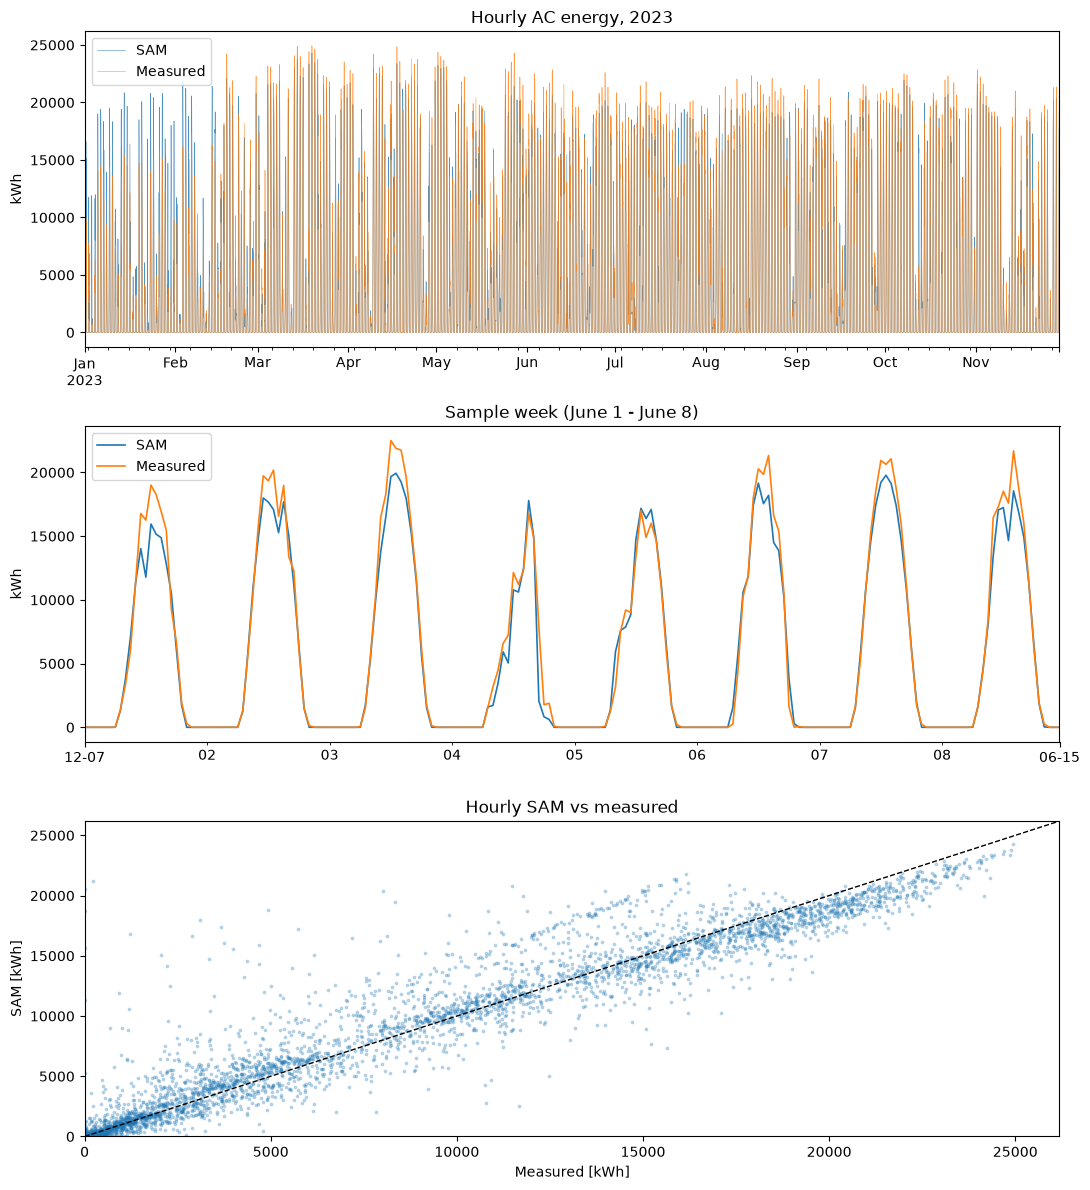

Annual SAM:      37,653,972 kWh
Annual measured: 36,768,113 kWh
Ratio SAM/meas:  1.024


In [85]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plot_year = 2023

# PVWatts hourly gen is kW in local standard time (no DST) -> kWh/h, aligned to the measured index tz
sam_index = pd.date_range(f'{plot_year}-01-01', periods=8760, freq='h', tz='Etc/GMT+5')
sam_hourly = pd.Series(gen_dict["hourly"][plot_year][0:8760], index=sam_index, name='SAM').tz_convert(hourly.index.tz) 

# + pd.DateOffset(days=1)  - correction for leap year offset

meas_hourly = hourly['site_ac_energy_kwh'].rename('Measured')

comp = pd.concat([sam_hourly, meas_hourly], axis=1).loc[str(plot_year)].dropna()

fig, axes = plt.subplots(3, 1, figsize=(11, 12))

# full year time series
comp.plot(ax=axes[0], lw=0.4, alpha=0.8)
axes[0].set(title=f'Hourly AC energy, {plot_year}', ylabel='kWh')

# one representative week
week = comp.loc[f'{plot_year}-06-01':f'{plot_year}-06-08']
week.plot(ax=axes[1], lw=1.2)
axes[1].set(title='Sample week (June 1 - June 8)', ylabel='kWh')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# scatter with 1:1 line
axes[2].scatter(comp['Measured'], comp['SAM'], s=3, alpha=0.25)
lims = [0, comp.max().max() * 1.05]
axes[2].plot(lims, lims, 'k--', lw=1)
axes[2].set(xlim=lims, ylim=lims, xlabel='Measured [kWh]', ylabel='SAM [kWh]',
            title='Hourly SAM vs measured')

fig.tight_layout()
plt.show()

print(f"Annual SAM:      {comp['SAM'].sum():,.0f} kWh")
print(f"Annual measured: {comp['Measured'].sum():,.0f} kWh")
print(f"Ratio SAM/meas:  {comp['SAM'].sum() / comp['Measured'].sum():.3f}")
